## Task

Cluster the MNIST dataset of handwritten digits using K-Means and visualize the prototypes.

### Voluntary task

Train a k-nearest-neighbor classifier to assign a label to the prototypes. Now use the labeled prototypes as data for another k-Nearest-Neighbor classifier. How does the classification quality differ, what influence does this approach have on the runtime?

In [1]:
import gzip
import os
import numpy as np

train_data = os.path.join("DataSets", "mnist", 
                          "train-images-idx3-ubyte.gz")
train_labels = os.path.join("DataSets", "mnist", "train-labels-idx1-ubyte.gz")

test_data = os.path.join("DataSets", "mnist", "t10k-images-idx3-ubyte.gz")
test_labels = os.path.join("DataSets", "mnist", "t10k-labels-idx1-ubyte.gz")

In [2]:
def mnist_images(filename):
    with gzip.open(filename, "rb") as file:
        data = np.frombuffer(file.read(), np.uint8, offset = 16)
        return data.reshape(-1, 28, 28) / 255
    
def mnist_labels(filename):
    with gzip.open(filename, "rb") as file:
        return np.frombuffer(file.read(), np.uint8, offset = 8)

X_train = mnist_images(train_data)
y_train = mnist_labels(train_labels)

X_test = mnist_images(test_data)
y_test = mnist_labels(test_labels)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


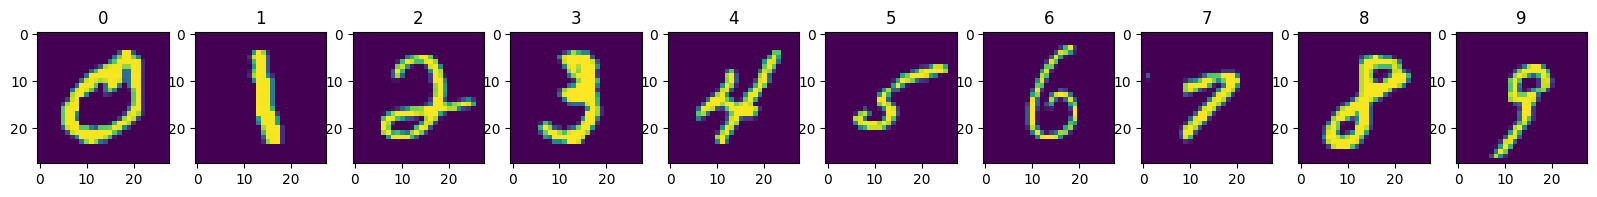

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt

f,ax = plt.subplots(1,10)
f.set_size_inches(20,4)

for i in range(0,10):
    plt.sca(ax[i])
    plt.imshow(X_train[y_train==i,:,:][1])
    plt.title(i)


In [4]:
from sklearn.cluster import KMeans

# ১. ২D ইমেজগুলোকে ১D ভেক্টরে ফ্ল্যাটেন করা (K-Means এ ইনপুট দেওয়ার জন্য)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# ২. ১০টি ক্লাস্টার নিয়ে K-Means অবজেক্ট তৈরি এবং মডেল ট্রেইন করা
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_train_flat)

print("K-Means Training Complete!")

K-Means Training Complete!


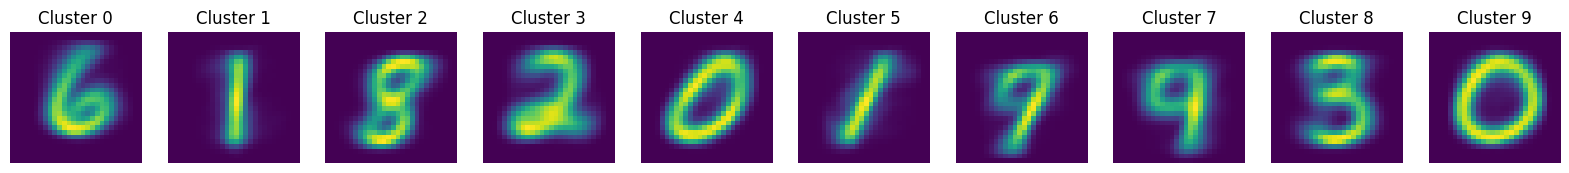

In [8]:
import matplotlib.pyplot as plt

# ১. ক্লাস্টার সেন্টার (Prototypes) নেওয়া
centroids = kmeans.cluster_centers_

# ২. সেন্টারগুলোকে আবার প্লট করার জন্য (28, 28) ইমেজে রূপান্তর করা
centroids_images = centroids.reshape(10, 28, 28)

# ৩. ১০টি প্রোটোটাইপ ইমেজ পাশাপাশি সাবপ্লট আকারে দেখানো
fig, ax = plt.subplots(1, 10, figsize=(20, 4))

for i in range(10):
    plt.sca(ax[i])
    plt.imshow(centroids_images[i], cmap='viridis') # কালারম্যাপ দেখতে সুন্দর লাগবে
    plt.title(f"Cluster {i}")
    plt.axis('off')

plt.show()

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

# ১. ১-NN ক্লাসিফায়ার ব্যবহার করে ১০টি প্রোটোটাইপের আসল লেবেল (০-৯) বের করা
knn_proto_labeler = KNeighborsClassifier(n_neighbors=1)
knn_proto_labeler.fit(X_train_flat, y_train)
prototype_labels = knn_proto_labeler.predict(centroids)

# ২. মডেল ১: সম্পূর্ণ ৬০,০০০ ডেটাসেট দিয়ে kNN ট্রেইন এবং টেস্ট করা
start_time = time.time()
knn_full = KNeighborsClassifier(n_neighbors=3)
knn_full.fit(X_train_flat, y_train)
y_pred_full = knn_full.predict(X_test_flat)
runtime_full = time.time() - start_time
accuracy_full = accuracy_score(y_test, y_pred_full)

# ৩. মডেল ২: শুধু ১০টি লেবেলড প্রোটোটাইপ ডেটা দিয়ে kNN ট্রেইন এবং টেস্ট করা
start_time = time.time()
knn_sparse = KNeighborsClassifier(n_neighbors=1) # ডেটা মাত্র ১০টি, তাই k=1
knn_sparse.fit(centroids, prototype_labels)
y_pred_sparse = knn_sparse.predict(X_test_flat)
runtime_sparse = time.time() - start_time
accuracy_sparse = accuracy_score(y_test, y_pred_sparse)

# ৪. দুটি পদ্ধতির চূড়ান্ত ফলাফল স্ক্রিনে প্রিন্ট করা
print("="*50)
print(f"Full Dataset -> Accuracy: {accuracy_full:.4f}, Runtime: {runtime_full:.2f} seconds")
print(f"Prototypes Only -> Accuracy: {accuracy_sparse:.4f}, Runtime: {runtime_sparse:.2f} seconds")
print("="*50)

Full Dataset -> Accuracy: 0.9705, Runtime: 9.80 seconds
Prototypes Only -> Accuracy: 0.5932, Runtime: 0.01 seconds


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1e91bd54-be52-46c8-8e4a-baf88d675b91' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>